# 04 — Subtype differential expression analysis

This notebook identifies exploratory gene expression signatures associated with major TCGA-BRCA molecular subtypes.

The goal is to compare transcriptomic profiles between selected groups and generate interpretable outputs such as volcano plots, top gene tables and subtype-level heatmaps.

This is an exploratory portfolio analysis, not a clinically validated differential expression workflow.

In [30]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from stats_utils import differential_expression_mannwhitney

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [31]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from stats_utils import differential_expression_mannwhitney

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [32]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

expression_path = PROCESSED_DIR / "expression_rsem_samples_by_gene.tsv"
metadata_path = PROCESSED_DIR / "clinical_marker_analysis_table.tsv"

print("Expression exists:", expression_path.exists())
print("Metadata exists:", metadata_path.exists())

Expression exists: True
Metadata exists: True


In [33]:
expression = pd.read_csv(expression_path, sep="\t")
metadata = pd.read_csv(metadata_path, sep="\t")

print("expression:", expression.shape)
print("metadata:", metadata.shape)

display(expression.head())
display(metadata.head())

expression: (1082, 20514)
metadata: (1082, 72)


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44,31.5787

,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y,SAMPLE_ID_ORIGINAL,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01,TCGA-3C-AALI-01,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01,TCGA-3C-AALK-01,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,

In [34]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

metadata = metadata.drop_duplicates(subset=id_cols).copy()

df = expression.merge(
    metadata[id_cols + ["SUBTYPE"]],
    on=id_cols,
    how="inner"
)

print("Merged table:", df.shape)

subtype_counts = df["SUBTYPE"].fillna("Unknown").value_counts()
display(subtype_counts)

Merged table: (1082, 20515)


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
Unknown        101
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

In [35]:
non_gene_cols = [
    "SAMPLE_ID",
    "SAMPLE_ID_ORIGINAL",
    "SAMPLE_ID_15",
    "PATIENT_ID_12",
    "SUBTYPE",
]

gene_cols = [
    col for col in expression.columns
    if col not in non_gene_cols
]

X_raw = df[gene_cols].apply(pd.to_numeric, errors="coerce")

# Remove genes with many missing values
missing_fraction = X_raw.isna().mean(axis=0)
genes_keep = missing_fraction[missing_fraction < 0.05].index.tolist()

X_raw = X_raw[genes_keep]
X_raw = X_raw.fillna(X_raw.median(axis=0))

# log2 transform
X_log = np.log2(X_raw + 1)

print("Raw expression:", X_raw.shape)
print("Log expression:", X_log.shape)

Raw expression: (1082, 20511)
Log expression: (1082, 20511)


In [36]:
# Keep genes expressed in at least 20% of samples and with some variance
expressed_fraction = (X_raw > 1).mean(axis=0)
gene_variance = X_log.var(axis=0)

filtered_genes = expressed_fraction[
    (expressed_fraction >= 0.20) &
    (gene_variance >= 0.05)
].index.tolist()

X_de = X_log[filtered_genes].copy()

print("Genes before filtering:", X_log.shape[1])
print("Genes after filtering:", X_de.shape[1])

Genes before filtering: 20511
Genes after filtering: 17651


In [37]:
metadata_de = df[["SAMPLE_ID_15", "PATIENT_ID_12", "SUBTYPE"]].copy()

# Ensure same index as X_de
metadata_de = metadata_de.loc[X_de.index].copy()

display(metadata_de.head())

,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA


In [38]:
comparisons = [
    ("BRCA_Basal", "BRCA_LumA"),
    ("BRCA_Her2", "BRCA_LumA"),
    ("BRCA_LumB", "BRCA_LumA"),
]

for group_a, group_b in comparisons:
    n_a = (metadata_de["SUBTYPE"] == group_a).sum()
    n_b = (metadata_de["SUBTYPE"] == group_b).sum()
    print(f"{group_a} vs {group_b}: n={n_a} vs n={n_b}")

BRCA_Basal vs BRCA_LumA: n=171 vs n=499
BRCA_Her2 vs BRCA_LumA: n=78 vs n=499
BRCA_LumB vs BRCA_LumA: n=197 vs n=499


In [39]:
de_results = {}

for group_a, group_b in comparisons:
    print(f"Running {group_a} vs {group_b}...")

    res = differential_expression_mannwhitney(
        expression_log=X_de,
        metadata=metadata_de,
        group_col="SUBTYPE",
        group_a=group_a,
        group_b=group_b,
        min_abs_log2fc=1.0,
    )

    comparison_name = f"{group_a}_vs_{group_b}".replace("BRCA_", "")
    de_results[comparison_name] = res

    outpath = TABLES_DIR / f"differential_expression_{comparison_name}.csv"
    res.to_csv(outpath, index=False)

    print(comparison_name, res.shape)
    display(res.head(10))

Running BRCA_Basal vs BRCA_LumA...
Basal_vs_LumA (17651, 14)


,gene,group_a,group_b,n_a,n_b,mean_log2_group_a,mean_log2_group_b,median_log2_group_a,median_log2_group_b,log2fc_group_a_vs_group_b,p_value,fdr,neg_log10_fdr,significant
9513,MLPH,BRCA_Basal,BRCA_LumA,171,499,7.426369,12.878640,7.720053,12.874138,-5.452271,1.092971e-84,1.929203e-80,79.714622,True
6170,GATA3,BRCA_Basal,BRCA_LumA,171,499,9.271444,13.671782,9.685732,13.664436,-4.400338,2.648483e-84,2.337419e-80,79.631263,True
384,AGR3,BRCA_Basal,BRCA_LumA,171,499,2.157008,11.111892,1.792522,11.254060,-8.954885,7.668015e-84,4.511605e-80,79.345669,True
5934,FOXA1,BRCA_Basal,BRCA_LumA,171,499,6.380753,12.849253,6.071456,12.884052,-6.468500,2.284936e-83,1.008285e-79,78.996417,True
15287,THSD4,BRCA_Basal,BRCA_LumA,171,499,7.327555,11.628734,7.311930,11.635800,-4.301179,3.529573e-83,1.246010e-79,78.904479,True
4656,DRAIC,BRCA_Basal,BRCA_LumA,171,499,1.387855,6.267563,1.263756,6.089918,-4.879709,5.492061e-83,1.615673e-79,78.791647,True
2522,CA12,BRCA_Basal,BRCA_LumA,171,499,8.136070,13.322779,8.064446,13.461684,-5.186709,7.429416e-83,1.873380e-79,78.727374,True
5172,ESR1,BRCA_Basal,BRCA_LumA,171,499,6.578133,13.327198,6.524611,13.361423,-6.749065,8.946664e-83,1.973969e-79,78.704660,True
3934,CT62,BRCA_Basal,BRCA_LumA,171,499,0.961757,5.651880,0.698485,5.694802,-4.690123,1.135868e-82,2.227690e-79,78.652145,True
2382,C6orf97,BRCA_Basal,BRCA_LumA,171,499,4.712643,9.048689,4.781297,9.114713,-4.336047,1.547783e-82,2.465033e-79,78.608177,True


Running BRCA_Her2 vs BRCA_LumA...
Her2_vs_LumA (17651, 14)


,gene,group_a,group_b,n_a,n_b,mean_log2_group_a,mean_log2_group_b,median_log2_group_a,median_log2_group_b,log2fc_group_a_vs_group_b,p_value,fdr,neg_log10_fdr,significant
5172,ESR1,BRCA_Her2,BRCA_LumA,78,499,8.029640,13.327198,7.628532,13.361423,-5.297558,6.438134e-40,1.136395e-35,34.944471,True
12703,RERG,BRCA_Her2,BRCA_LumA,78,499,7.652854,10.522388,7.535654,10.577561,-2.869534,1.013152e-38,8.941577e-35,34.048586,True
13164,RRM2,BRCA_Her2,BRCA_LumA,78,499,11.069055,8.998933,10.897926,9.103673,2.070122,2.013856e-38,1.184886e-34,33.926323,True
6595,GPR77,BRCA_Her2,BRCA_LumA,78,499,3.797808,7.007955,3.632152,7.095133,-3.210147,2.374366e-37,9.819511e-34,33.007910,True
10680,NXNL2,BRCA_Her2,BRCA_LumA,78,499,1.254698,4.845318,1.008356,5.024510,-3.590620,2.781574e-37,9.819511e-34,33.007910,True
1323,BCL2,BRCA_Her2,BRCA_LumA,78,499,8.315879,11.004657,8.154030,11.054937,-2.688778,5.669733e-37,1.667941e-33,32.777819,True
7433,IGF1R,BRCA_Her2,BRCA_LumA,78,499,9.626189,12.213120,9.420093,12.297750,-2.586931,1.622523e-36,4.091307e-33,32.388138,True
4190,DBNDD2,BRCA_Her2,BRCA_LumA,78,499,8.382419,10.365878,8.364361,10.428915,-1.983459,4.244752e-36,9.365514e-33,32.028468,True
2382,C6orf97,BRCA_Her2,BRCA_LumA,78,499,5.831383,9.048689,5.525644,9.114713,-3.217306,7.579623e-36,1.486532e-32,31.827826,True
11323,PGR,BRCA_Her2,BRCA_LumA,78,499,5.716348,10.906441,5.274617,11.445961,-5.190093,8.941724e-36,1.578304e-32,31.801809,True


Running BRCA_LumB vs BRCA_LumA...
LumB_vs_LumA (17651, 14)


,gene,group_a,group_b,n_a,n_b,mean_log2_group_a,mean_log2_group_b,median_log2_group_a,median_log2_group_b,log2fc_group_a_vs_group_b,p_value,fdr,neg_log10_fdr,significant
15831,TPX2,BRCA_LumB,BRCA_LumA,197,499,11.009484,9.505381,11.108302,9.639095,1.504103,1.136238e-63,2.005573e-59,58.697761,True
3245,CEP55,BRCA_LumB,BRCA_LumA,197,499,9.127199,7.669139,9.111962,7.826580,1.458060,6.351354e-63,5.605388e-59,58.251394,True
1186,AURKA,BRCA_LumB,BRCA_LumA,197,499,9.480404,7.916297,9.440346,7.861769,1.564107,9.595244e-62,5.645521e-58,57.248296,True
10075,NCAPG,BRCA_LumB,BRCA_LumA,197,499,9.340369,7.884348,9.342995,7.949844,1.456020,1.086357e-60,4.793823e-57,56.319318,True
5960,FOXM1,BRCA_LumB,BRCA_LumA,197,499,10.315041,8.776944,10.392757,8.881802,1.538097,3.844265e-60,1.357102e-56,55.867387,True
9236,MCM10,BRCA_LumB,BRCA_LumA,197,499,8.231784,6.512581,8.258199,6.634432,1.719202,5.744478e-60,1.689930e-56,55.772131,True
13693,SGOL1,BRCA_LumB,BRCA_LumA,197,499,7.047263,5.367834,7.059853,5.556203,1.679429,1.343183e-59,3.386931e-56,55.470194,True
3213,CENPA,BRCA_LumB,BRCA_LumA,197,499,7.337838,5.807420,7.328648,5.960618,1.530418,5.940674e-59,1.310735e-55,54.882485,True
2907,CCNA2,BRCA_LumB,BRCA_LumA,197,499,9.312083,7.878391,9.346773,7.981544,1.433692,2.056300e-58,4.032862e-55,54.394387,True
14468,SPAG5,BRCA_LumB,BRCA_LumA,197,499,10.165070,8.678568,10.196455,8.690354,1.486502,6.225788e-58,1.098914e-54,53.959036,True


In [40]:
def plot_volcano(
    de_df,
    comparison_name,
    log2fc_col="log2fc_group_a_vs_group_b",
    fdr_col="fdr",
    fdr_threshold=0.05,
    log2fc_threshold=1.0,
    top_n_labels=10,
):
    plot_df = de_df.copy()
    plot_df["minus_log10_fdr"] = -np.log10(plot_df[fdr_col].clip(lower=1e-300))

    plot_df["category"] = "Not significant"
    plot_df.loc[
        (plot_df[fdr_col] < fdr_threshold) &
        (plot_df[log2fc_col] >= log2fc_threshold),
        "category"
    ] = "Higher in group A"

    plot_df.loc[
        (plot_df[fdr_col] < fdr_threshold) &
        (plot_df[log2fc_col] <= -log2fc_threshold),
        "category"
    ] = "Higher in group B"

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x=log2fc_col,
        y="minus_log10_fdr",
        hue="category",
        alpha=0.7,
        s=18
    )

    plt.axvline(log2fc_threshold, linestyle="--", linewidth=1)
    plt.axvline(-log2fc_threshold, linestyle="--", linewidth=1)
    plt.axhline(-np.log10(fdr_threshold), linestyle="--", linewidth=1)

    label_df = (
        plot_df[plot_df[fdr_col] < fdr_threshold]
        .sort_values("minus_log10_fdr", ascending=False)
        .head(top_n_labels)
    )

    for _, row in label_df.iterrows():
        plt.text(
            row[log2fc_col],
            row["minus_log10_fdr"],
            row["gene"],
            fontsize=8
        )

    plt.title(f"Volcano plot: {comparison_name}")
    plt.xlabel("log2 fold-change")
    plt.ylabel("-log10(FDR)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    safe_name = comparison_name.replace(" ", "_").replace("/", "_")
    plt.savefig(FIGURES_DIR / f"volcano_{safe_name}.png", dpi=300)
    plt.show()

In [41]:
def plot_volcano(
    de_df,
    comparison_name,
    log2fc_col="log2fc_group_a_vs_group_b",
    fdr_col="fdr",
    fdr_threshold=0.05,
    log2fc_threshold=1.0,
    top_n_labels=10,
):
    plot_df = de_df.copy()
    plot_df["minus_log10_fdr"] = -np.log10(plot_df[fdr_col].clip(lower=1e-300))

    plot_df["category"] = "Not significant"
    plot_df.loc[
        (plot_df[fdr_col] < fdr_threshold) &
        (plot_df[log2fc_col] >= log2fc_threshold),
        "category"
    ] = "Higher in group A"

    plot_df.loc[
        (plot_df[fdr_col] < fdr_threshold) &
        (plot_df[log2fc_col] <= -log2fc_threshold),
        "category"
    ] = "Higher in group B"

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x=log2fc_col,
        y="minus_log10_fdr",
        hue="category",
        alpha=0.7,
        s=18
    )

    plt.axvline(log2fc_threshold, linestyle="--", linewidth=1)
    plt.axvline(-log2fc_threshold, linestyle="--", linewidth=1)
    plt.axhline(-np.log10(fdr_threshold), linestyle="--", linewidth=1)

    genes_to_label = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "KRT5",
    "KRT14",
    "KRT17",
    "BRCA1",
    "BRCA2",
    ]

    label_df = plot_df[
        plot_df["gene"].isin(genes_to_label)
    ].copy()

    for _, row in label_df.iterrows():
        plt.text(
            row[log2fc_col],
            row["minus_log10_fdr"],
            row["gene"],
            fontsize=8
        )

    plt.title(f"Volcano plot: {comparison_name}")
    plt.xlabel("log2 fold-change")
    plt.ylabel("-log10(FDR)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    safe_name = comparison_name.replace(" ", "_").replace("/", "_")
    plt.savefig(FIGURES_DIR / f"volcano_{safe_name}.png", dpi=300)
    plt.show()

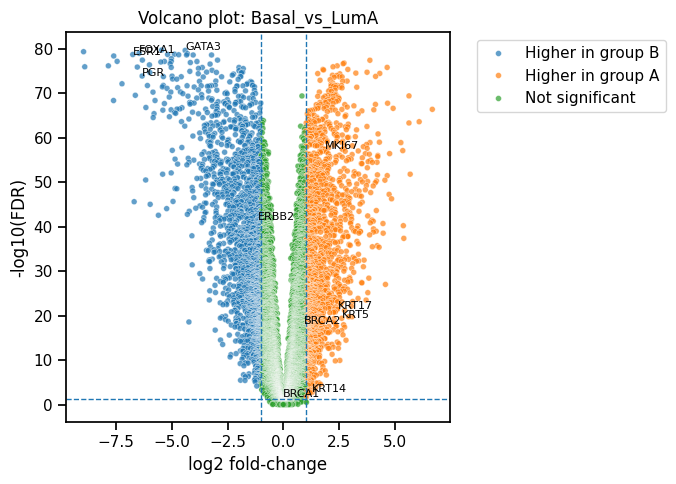

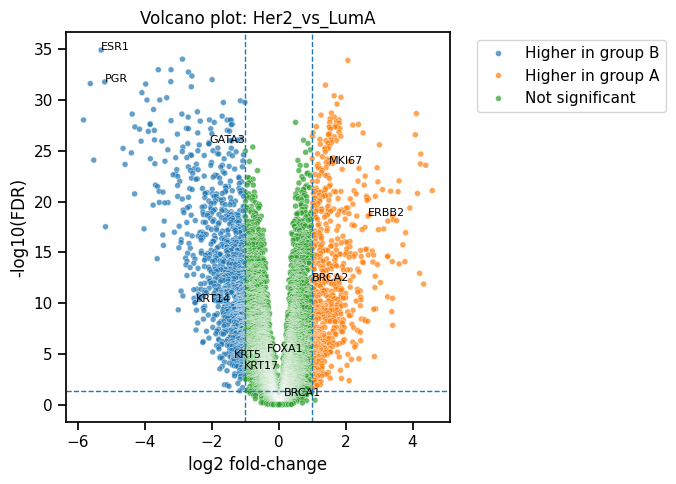

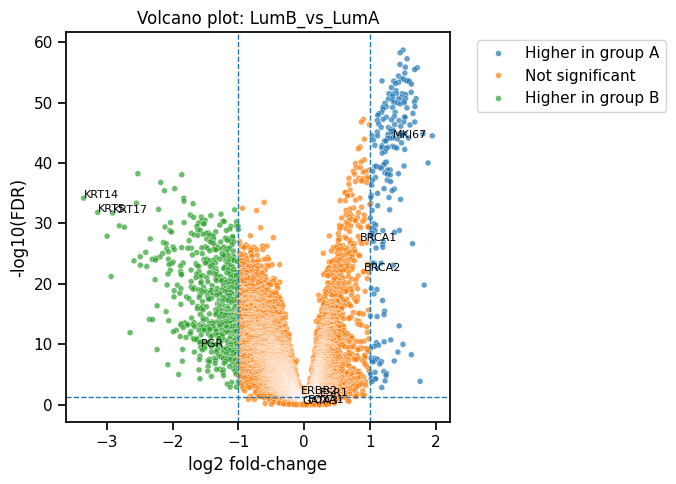

In [42]:
for comparison_name, res in de_results.items():
    plot_volcano(res, comparison_name=comparison_name)

In [43]:
top_gene_tables = []

for comparison_name, res in de_results.items():
    top_up = (
        res[res["log2fc_group_a_vs_group_b"] > 0]
        .sort_values(["fdr", "log2fc_group_a_vs_group_b"], ascending=[True, False])
        .head(15)
        .copy()
    )

    top_down = (
        res[res["log2fc_group_a_vs_group_b"] < 0]
        .sort_values(["fdr", "log2fc_group_a_vs_group_b"], ascending=[True, True])
        .head(15)
        .copy()
    )

    top_up["direction"] = "higher_in_group_a"
    top_down["direction"] = "higher_in_group_b"

    top = pd.concat([top_up, top_down], axis=0)
    top["comparison"] = comparison_name

    top_gene_tables.append(top)

top_genes_all = pd.concat(top_gene_tables, axis=0)

display(
    top_genes_all[
        [
            "comparison",
            "gene",
            "direction",
            "log2fc_group_a_vs_group_b",
            "fdr",
            "mean_log2_group_a",
            "mean_log2_group_b",
        ]
    ]
)

top_genes_all.to_csv(TABLES_DIR / "top_differential_expression_genes_all_comparisons.csv", index=False)

,comparison,gene,direction,log2fc_group_a_vs_group_b,fdr,mean_log2_group_a,mean_log2_group_b
5936,Basal_vs_LumA,FOXC1,higher_in_group_a,3.883351,3.813688e-78,10.888137,7.004787
3056,Basal_vs_LumA,CDC20,higher_in_group_a,2.725385,1.605853e-77,10.934030,8.208645
3213,Basal_vs_LumA,CENPA,higher_in_group_a,2.685668,2.232338e-77,8.493089,5.807420
8128,Basal_vs_LumA,KIF2C,higher_in_group_a,2.416338,6.822302e-77,10.310027,7.893689
3090,Basal_vs_LumA,CDCA8,higher_in_group_a,2.229718,1.114326e-76,10.050295,7.820577
...,...,...,...,...,...,...,...
4020,LumB_vs_LumA,CX3CR1,higher_in_group_b,-1.688704,5.560183e-34,6.112864,7.801567
8939,LumB_vs_LumA,LTBP4,higher_in_group_b,-0.935311,3.167859e-33,8.882016,9.817328
9433,LumB_vs_LumA,MIA,higher_in_group_b,-2.212573,4.823463e-33,2.373648,4.586221
8443,LumB_vs_LumA,LEPREL1,higher_in_group_b,-1.056379,5.701759e-33,5.795387,6.851765


In [44]:
known_brca_genes = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "TP53",
    "PIK3CA",
    "BRCA1",
    "BRCA2",
    "KRT5",
    "KRT14",
    "KRT17",
    "EPCAM",
]

for comparison_name, res in de_results.items():
    print(f"\n{comparison_name}")
    known_present = res[res["gene"].isin(known_brca_genes)].copy()
    known_present = known_present.sort_values("fdr")
    display(
        known_present[
            [
                "gene",
                "log2fc_group_a_vs_group_b",
                "fdr",
                "mean_log2_group_a",
                "mean_log2_group_b",
            ]
        ]
    )


Basal_vs_LumA


,gene,log2fc_group_a_vs_group_b,fdr,mean_log2_group_a,mean_log2_group_b
6170,GATA3,-4.400338,2.337419e-80,9.271444,13.671782
5934,FOXA1,-6.468500,1.008285e-79,6.380753,12.849253
5172,ESR1,-6.749065,1.973969e-79,6.578133,13.327198
11323,PGR,-6.328717,1.338553e-74,4.577724,10.906441
9479,MKI67,1.857653,3.846490e-58,11.848552,9.990898
5123,ERBB2,-1.149644,2.674761e-42,11.816162,12.965807
5079,EPCAM,0.784353,3.164688e-33,12.617648,11.833295
8280,KRT17,2.428286,3.713014e-22,11.765549,9.337263
8293,KRT5,2.620479,3.986341e-20,11.964252,9.343774
1462,BRCA2,0.931040,7.801982e-19,7.722726,6.791687



Her2_vs_LumA


,gene,log2fc_group_a_vs_group_b,fdr,mean_log2_group_a,mean_log2_group_b
5172,ESR1,-5.297558,1.136395e-35,8.029640,13.327198
11323,PGR,-5.190093,1.578304e-32,5.716348,10.906441
6170,GATA3,-2.079142,1.501577e-26,11.592640,13.671782
9479,MKI67,1.494864,1.781394e-24,11.485763,9.990898
5123,ERBB2,2.670758,2.654315e-19,15.636565,12.965807
5079,EPCAM,0.827931,1.056467e-17,12.661226,11.833295
1462,BRCA2,1.005067,6.118274e-13,7.796754,6.791687
8277,KRT14,-2.480785,8.386163e-11,6.607302,9.088087
5934,FOXA1,-0.346961,7.221260e-06,12.502292,12.849253
8293,KRT5,-1.344088,2.366630e-05,7.999686,9.343774



LumB_vs_LumA


,gene,log2fc_group_a_vs_group_b,fdr,mean_log2_group_a,mean_log2_group_b
9479,MKI67,1.350174,7.169760e-45,11.341073,9.990898
8277,KRT14,-3.352886,6.548923e-35,5.735202,9.088087
8293,KRT5,-3.137315,1.540433e-32,6.206458,9.343774
8280,KRT17,-2.912963,1.913241e-32,6.424300,9.337263
1461,BRCA1,0.851789,8.402969e-28,9.127114,8.275325
1462,BRCA2,0.911299,8.217047e-23,7.702985,6.791687
5079,EPCAM,0.462155,5.403385e-14,12.295450,11.833295
11323,PGR,-1.572381,3.454701e-10,9.334060,10.906441
5123,ERBB2,-0.051606,1.889744e-02,12.914201,12.965807
5172,ESR1,0.232824,3.914698e-02,13.560022,13.327198


In [45]:
signature_genes = []

for comparison_name, res in de_results.items():
    top_up = (
        res[res["significant"] & (res["log2fc_group_a_vs_group_b"] > 0)]
        .sort_values("fdr")
        .head(10)["gene"]
        .tolist()
    )

    top_down = (
        res[res["significant"] & (res["log2fc_group_a_vs_group_b"] < 0)]
        .sort_values("fdr")
        .head(10)["gene"]
        .tolist()
    )

    signature_genes.extend(top_up + top_down)

# Keep unique order
signature_genes = list(dict.fromkeys(signature_genes))

print("Signature genes:", len(signature_genes))
print(signature_genes[:30])

Signature genes: 53
['FOXC1', 'CDC20', 'CENPA', 'KIF2C', 'CDCA8', 'PSAT1', 'B3GNT5', 'IFRD1', 'CENPN', 'CDCA7', 'MLPH', 'GATA3', 'AGR3', 'FOXA1', 'THSD4', 'DRAIC', 'CA12', 'ESR1', 'CT62', 'C6orf97', 'RRM2', 'AURKA', 'MPHOSPH6', 'CEP55', 'SOX11', 'GGCT', 'SHCBP1', 'CDKN3', 'RERG', 'GPR77']


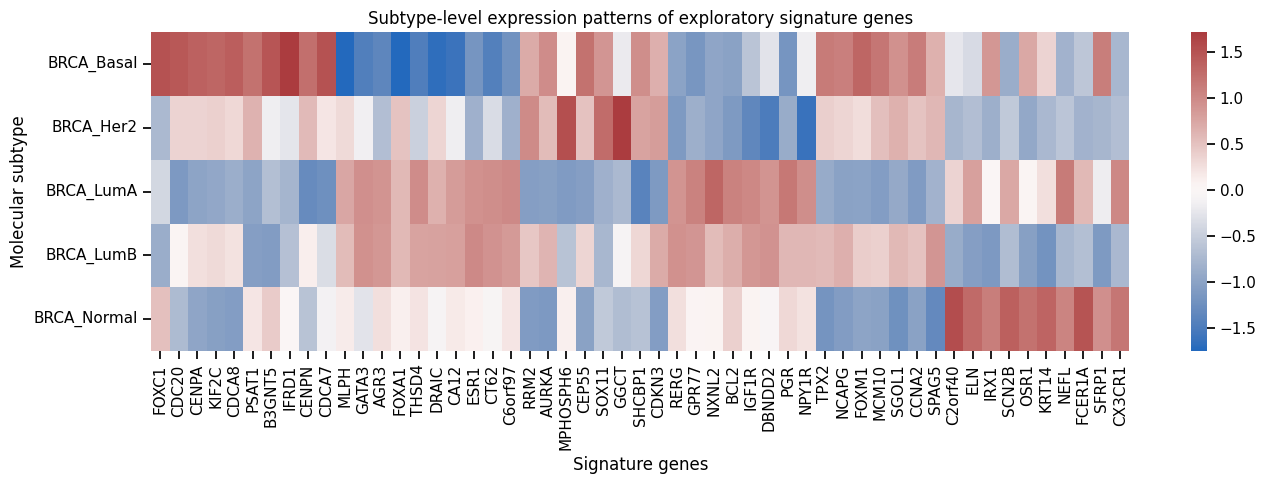

In [46]:
subtypes_for_heatmap = [
    "BRCA_Basal",
    "BRCA_Her2",
    "BRCA_LumA",
    "BRCA_LumB",
    "BRCA_Normal",
]

heatmap_df = X_log[signature_genes].copy()
heatmap_df["SUBTYPE"] = metadata_de["SUBTYPE"].values

heatmap_df = heatmap_df[heatmap_df["SUBTYPE"].isin(subtypes_for_heatmap)]

subtype_medians = (
    heatmap_df
    .groupby("SUBTYPE")[signature_genes]
    .median()
    .loc[subtypes_for_heatmap]
)

# Z-score genes across subtypes for visualization
subtype_medians_z = (
    subtype_medians - subtype_medians.mean(axis=0)
) / subtype_medians.std(axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(
    subtype_medians_z,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)
plt.title("Subtype-level expression patterns of exploratory signature genes")
plt.xlabel("Signature genes")
plt.ylabel("Molecular subtype")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "subtype_signature_gene_heatmap.png", dpi=300)
plt.show()

subtype_medians.to_csv(TABLES_DIR / "subtype_signature_gene_median_expression.csv")
subtype_medians_z.to_csv(TABLES_DIR / "subtype_signature_gene_median_expression_zscore.csv")

In [47]:
summary_rows = []

for comparison_name, res in de_results.items():
    n_significant = res["significant"].sum()
    n_up = (
        res["significant"] &
        (res["log2fc_group_a_vs_group_b"] > 0)
    ).sum()
    n_down = (
        res["significant"] &
        (res["log2fc_group_a_vs_group_b"] < 0)
    ).sum()

    summary_rows.append(
        {
            "comparison": comparison_name,
            "n_tested_genes": res.shape[0],
            "n_significant_genes": n_significant,
            "n_higher_in_group_a": n_up,
            "n_higher_in_group_b": n_down,
        }
    )

de_summary = pd.DataFrame(summary_rows)

display(de_summary)

de_summary.to_csv(TABLES_DIR / "differential_expression_summary.csv", index=False)

,comparison,n_tested_genes,n_significant_genes,n_higher_in_group_a,n_higher_in_group_b
0,Basal_vs_LumA,17651,3634,1668,1966
1,Her2_vs_LumA,17651,1742,692,1050
2,LumB_vs_LumA,17651,815,200,615


In [48]:
known_brca_genes = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "KRT5",
    "KRT14",
    "KRT17",
    "EPCAM",
    "TP53",
    "PIK3CA",
    "BRCA1",
    "BRCA2",
]

known_gene_fc_tables = []

for comparison_name, res in de_results.items():
    known = res[res["gene"].isin(known_brca_genes)].copy()
    known["comparison"] = comparison_name

    known["higher_in"] = np.where(
        known["log2fc_group_a_vs_group_b"] > 0,
        known["group_a"],
        known["group_b"]
    )

    known_gene_fc_tables.append(known)

known_gene_fc = pd.concat(known_gene_fc_tables, axis=0)

display(
    known_gene_fc[
        [
            "comparison",
            "gene",
            "log2fc_group_a_vs_group_b",
            "fdr",
            "higher_in",
            "mean_log2_group_a",
            "mean_log2_group_b",
        ]
    ].sort_values(["comparison", "log2fc_group_a_vs_group_b"])
)

known_gene_fc.to_csv(
    TABLES_DIR / "known_brca_marker_log2fc_by_comparison.csv",
    index=False
)

,comparison,gene,log2fc_group_a_vs_group_b,fdr,higher_in,mean_log2_group_a,mean_log2_group_b
5172,Basal_vs_LumA,ESR1,-6.749065,1.973969e-79,BRCA_LumA,6.578133,13.327198
5934,Basal_vs_LumA,FOXA1,-6.468500,1.008285e-79,BRCA_LumA,6.380753,12.849253
11323,Basal_vs_LumA,PGR,-6.328717,1.338553e-74,BRCA_LumA,4.577724,10.906441
6170,Basal_vs_LumA,GATA3,-4.400338,2.337419e-80,BRCA_LumA,9.271444,13.671782
5123,Basal_vs_LumA,ERBB2,-1.149644,2.674761e-42,BRCA_LumA,11.816162,12.965807
15775,Basal_vs_LumA,TP53,-0.101943,2.383703e-01,BRCA_LumA,10.469493,10.571436
1461,Basal_vs_LumA,BRCA1,-0.017410,2.193727e-02,BRCA_LumA,8.257915,8.275325
11432,Basal_vs_LumA,PIK3CA,0.322709,3.262137e-05,BRCA_Basal,9.233391,8.910682
5079,Basal_vs_LumA,EPCAM,0.784353,3.164688e-33,BRCA_Basal,12.617648,11.833295
1462,Basal_vs_LumA,BRCA2,0.931040,7.801982e-19,BRCA_Basal,7.722726,6.791687


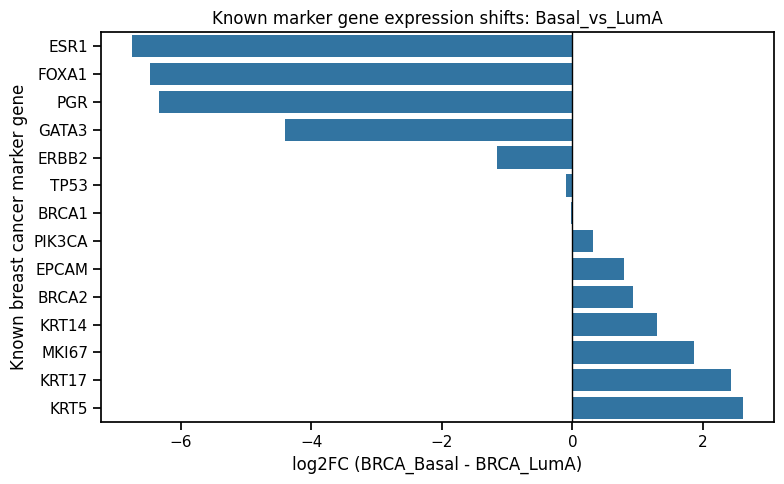

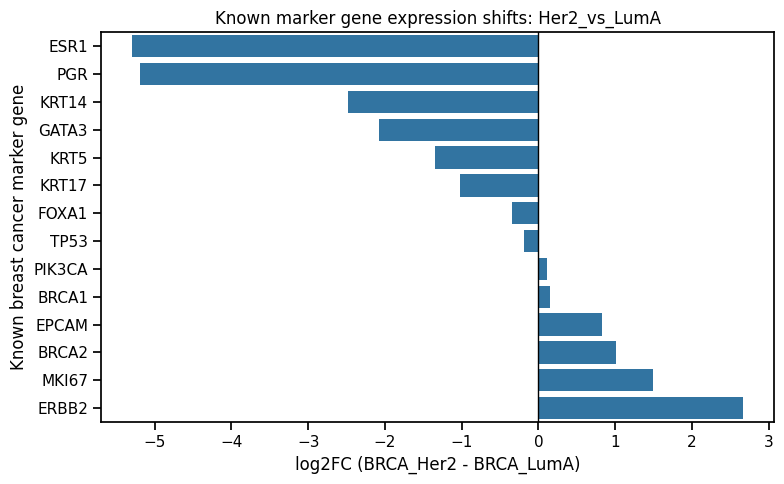

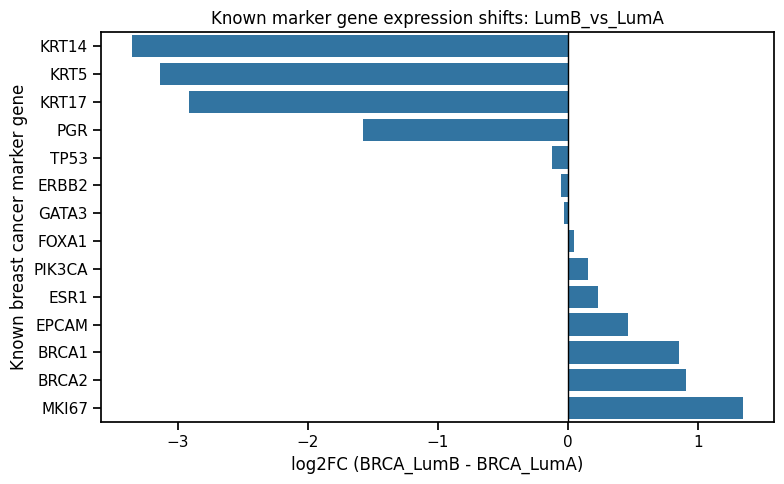

In [49]:
for comparison_name in known_gene_fc["comparison"].unique():
    plot_df = known_gene_fc[known_gene_fc["comparison"] == comparison_name].copy()
    plot_df = plot_df.sort_values("log2fc_group_a_vs_group_b")

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=plot_df,
        x="log2fc_group_a_vs_group_b",
        y="gene"
    )

    plt.axvline(0, color="black", linewidth=1)

    group_a = plot_df["group_a"].iloc[0]
    group_b = plot_df["group_b"].iloc[0]

    plt.title(f"Known marker gene expression shifts: {comparison_name}")
    plt.xlabel(f"log2FC ({group_a} - {group_b})")
    plt.ylabel("Known breast cancer marker gene")
    plt.tight_layout()

    safe_name = comparison_name.replace(" ", "_").replace("/", "_")
    plt.savefig(FIGURES_DIR / f"known_marker_log2fc_{safe_name}.png", dpi=300)
    plt.show()

## Preliminary interpretation

This exploratory differential expression analysis compares major TCGA-BRCA molecular subtypes using log-transformed bulk RNA-seq expression.

The goal is not to establish clinically validated biomarkers, but to identify whether known and candidate subtype-associated expression patterns are recovered from public data.

Key points to evaluate:

1. Basal-like tumours should show a distinct expression profile compared with Luminal A tumours.
2. Luminal A tumours are expected to show higher expression of hormone receptor/luminal markers such as ESR1, PGR, FOXA1 and GATA3.
3. HER2-enriched tumours may show higher ERBB2 expression relative to Luminal A.
4. Luminal B tumours may show expression patterns consistent with higher proliferation compared with Luminal A.
5. The subtype-level heatmap can be used as a compact visual summary of biologically interpretable subtype signatures.

These results complement the previous PCA and clustering analysis. While unsupervised clustering only partially recovers known subtype annotations, differential expression directly asks which genes distinguish predefined molecular groups.

“The differential expression analysis recovered expected subtype-associated patterns. Basal-like tumours showed higher expression of basal/cytokeratin and proliferation-associated markers such as KRT5, KRT17 and MKI67, while Luminal A tumours showed higher expression of luminal hormone-related markers such as ESR1, PGR, FOXA1 and GATA3. HER2-enriched tumours showed increased ERBB2 expression compared with Luminal A. These results support the biological validity of the subtype annotations and provide interpretable marker-level context for the global transcriptomic stratification.”